1.Import Required Libraries
Explanation

First, import the Python libraries required for:

Loading the dataset

Data manipulation

Visualization

Standardization

PCA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

2. Load the Wine Dataset

The Wine dataset is already available in scikit-learn.

In [2]:
wine = load_wine()

X = wine.data
y = wine.target


3. Understand the Dataset

Let's display the feature names.

In [3]:
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


4. Create a DataFrame

It is easier to understand the dataset using Pandas.

In [4]:
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

6. Check for Missing Values

In [6]:
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


7. Basic Statistical Analysis

In [7]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


8. Separate Features and Target

For PCA, we should apply PCA to the features, not the target class.

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

9. Why Do We Need Standardization?

This is a very important step in PCA.

Look at the scales of some features:

Alcohol       → around 14
Magnesium     → around 100
Proline       → around 1000

10. Standardize the Dataset

We use StandardScaler.

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

11. Verify Standardization

In [10]:
print("Mean:")
print(X_scaled.mean(axis=0))

print("\nStandard Deviation:")
print(X_scaled.std(axis=0))

Mean:
[-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17  0.00000000e+00 -3.99181312e-16  3.59263181e-16
 -1.19754394e-16  2.49488320e-17  1.99590656e-16  3.19345050e-16
 -1.59672525e-16]

Standard Deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
# 4. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [27]:
# 5. Explained variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)


Explained variance ratio:
[0.36198848 0.1920749 ]


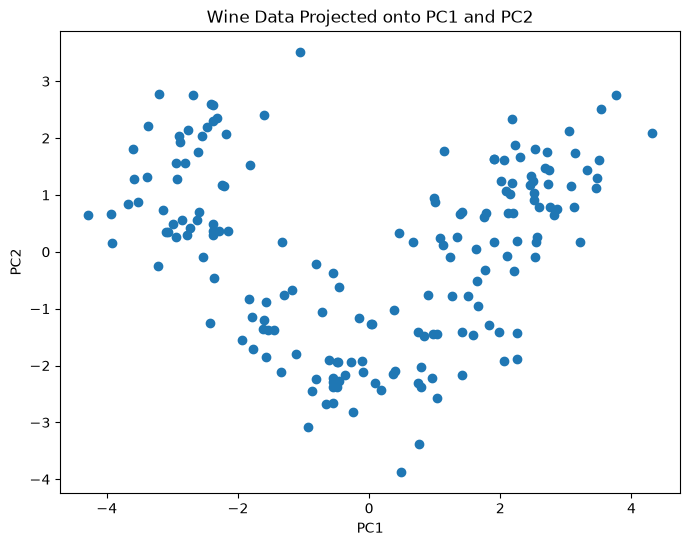

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Data Projected onto PC1 and PC2")

plt.show()

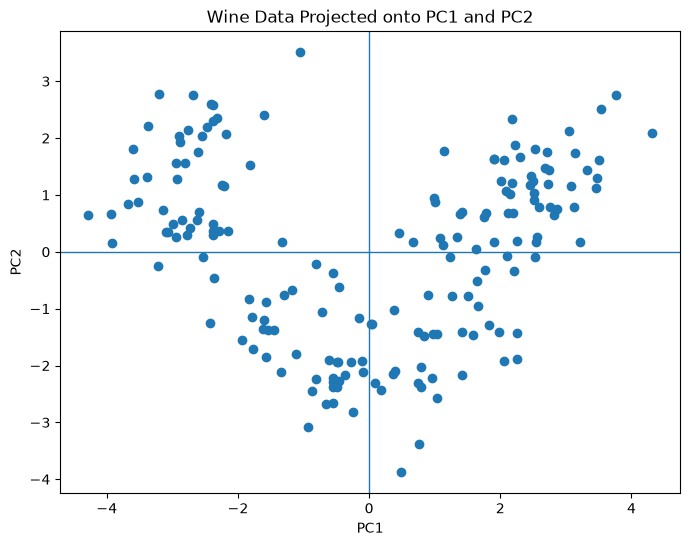

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Show PC1 and PC2 axes
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Data Projected onto PC1 and PC2")

plt.show()

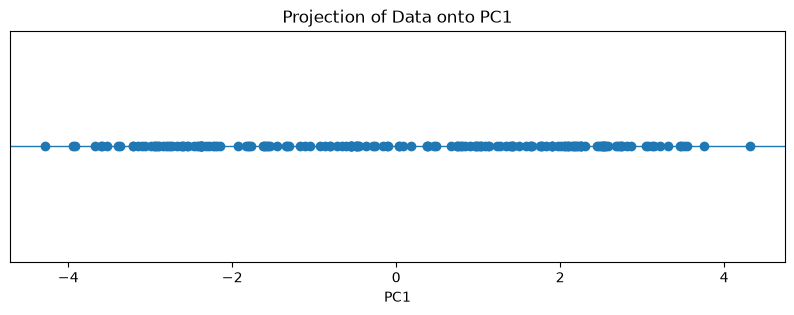

In [30]:
import matplotlib.pyplot as plt

# PC1 scores
pc1 = X_scaled @ pca.components_[0]

plt.figure(figsize=(10, 3))

plt.scatter(pc1, [0] * len(pc1))

plt.axhline(0, linewidth=1)

plt.xlabel("PC1")
plt.title("Projection of Data onto PC1")

plt.yticks([])

plt.show()

In [31]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=wine.feature_names
)
loadings

,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


## 12. What Do We Do With PCA Output? (Final Step)

So far we have reduced 13 features down to 2 principal components and
visualized them. But PCA is normally a **preprocessing step**, not the
final goal. Now that we have `X_pca`, we typically do one of these:

1. **Use the reduced data to train a machine learning model**
   (faster training, fewer features, often less overfitting)
2. **Compare performance**: model trained on all 13 features vs.
   model trained on just 2 principal components
3. **Save the transformed data and the fitted PCA model** so it can be
   reused later on new data without refitting

Below we do all three: train a classifier on the PCA-reduced data,
compare it against the original features, and save both the data and
the model to disk.

## 15. Predicting on a New, Unseen Wine Sample

Important: even though our final model only takes 2 numbers (PC1, PC2)
as input, we still need all 13 original features for any new sample.
That's because PC1 and PC2 are *calculated from* the 13 features — we
can't skip that step.

The correct pipeline for a new sample is:

**13 raw features → scaler.transform() → pca.transform() → 2 PCA values → model.predict()**

We must reuse the exact same `scaler` and `pca` objects that were
fitted on the training data (loaded back with joblib), not refit them
on the new sample.